Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (200, 4)
<bound method NDFrame.head of         TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[200 rows x 4 columns]>

Descriptive stst:
           count      mean        std  min     25%     50%      75%    max
TV         200.0  147.0425  85.854236  0.7  74.375  149.75  218.825  296.4
Radio      200.0   23.2640  14.846809  0.0   9.975   22.90   36.525   49.6
Newspaper  200.0   30.5540  21.778621  0.3  12.750   25.75   45.100  114.0
Sales      200.0   15.1305   5.283892  1.6  11.00

<Figure size 640x480 with 0 Axes>

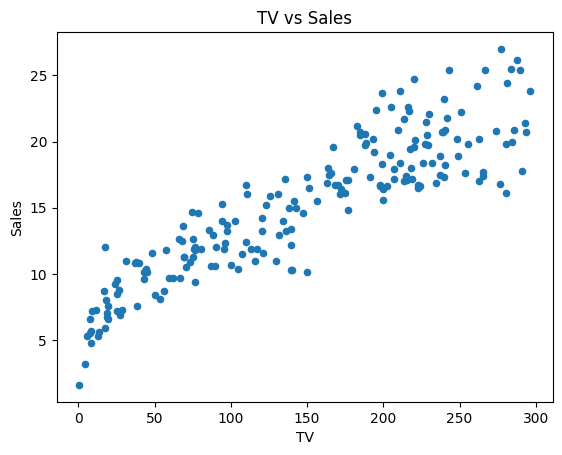


=== Simple Linear Regression (Sales ~ TV) ===
Intercept(b0): 6.974821488229891
Coefficient TV (b1): 0.055464770469558874


Prediksi Sales jika TV=150: 15.294537058663721
Prediksi Sales jika TV=500: 34.70720672300933




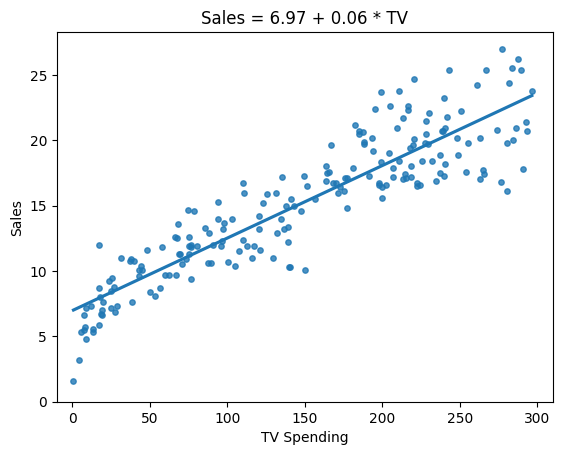

In [18]:
from re import X
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

from google.colab import drive
drive.mount('/content/drive')


DATA_PATH = "/content/drive/MyDrive/ML/Dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print(df.head)

print("\nDescriptive stst:")
print(df.describe().T)

plt.figure()
df.plot(kind='scatter', x='TV', y='Sales')
plt.title('TV vs Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

X = df[["TV"]]
y = df[["Sales"]]

reg_model = LinearRegression().fit(X, y)

print("\n=== Simple Linear Regression (Sales ~ TV) ===")
print("Intercept(b0):", reg_model.intercept_[0])
print("Coefficient TV (b1):", reg_model.coef_[0] [0])

print("\n")

tv_150 = reg_model.intercept_[0] + reg_model.coef_[0] [0] * 150
tv_500 = reg_model.intercept_[0] + reg_model.coef_[0] [0] * 500
print ("Prediksi Sales jika TV=150:", tv_150)
print ("Prediksi Sales jika TV=500:", tv_500)

print("\n")

plt.figure()
sns.regplot(x=X, y=y, scatter_kws={'s': 15}, ci=False)
plt.title(f"Sales = {reg_model.intercept_[0]:.2f} + {reg_model.coef_[0][0]:.2f} * TV")
plt.xlabel("TV Spending")
plt.ylabel("Sales")
plt.xlim(-10, 310)
plt.ylim(bottom=0)
plt.show()